# 05 Transfer Learning on Candlestick Images

Generate temporally labeled chart images, compare fine-tuning with frozen feature extraction, and inspect model attention with Grad-CAM. `FAST_MODE` uses a 20-session image stride and two training epochs; disable it for the full experiment.

## 1 Generate candlestick images

In [1]:
from pathlib import Path
import copy
import random
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from torchvision.models import ResNet18_Weights, resnet18

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
IMAGE_ROOT = DATA_DIR / "chart_images_30d_224"
IMAGE_ROOT.mkdir(parents=True, exist_ok=True)

DEMO_SCRIPT = PROJECT_ROOT / "demos" / "05_chart_image_generator.py"
print("Expected demo script:", DEMO_SCRIPT)
print("Demo script found:", DEMO_SCRIPT.exists())

# The curriculum explicitly refers to demos/05_chart_image_generator.py.
# The standalone demo exposes the same rendering approach. The local helper keeps
# this notebook self-contained for learners reading it from top to bottom.

def find_market_data_path():
    candidates = [
        DATA_DIR / "sp500_stocks.csv",
        DATA_DIR / "raw" / "sp500_stocks.csv",
        DATA_DIR / "sp500_market_data.csv",
        DATA_DIR / "stocks.csv",
    ]
    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Could not find the raw stock CSV under ../data."
    )


def load_market_data():
    path = find_market_data_path()
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]

    rename_map = {
        "ticker": "Ticker",
        "symbol": "Ticker",
        "date": "Date",
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "adj close": "Adj Close",
        "adj_close": "Adj Close",
        "volume": "Volume",
    }

    df = df.rename(
        columns={
            c: rename_map[c.strip().lower()]
            for c in df.columns
            if c.strip().lower() in rename_map
        }
    )

    required = {"Ticker", "Date", "Open", "High", "Low", "Close", "Volume"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Missing OHLCV columns: {sorted(missing)}")

    if "Adj Close" not in df.columns:
        df["Adj Close"] = df["Close"]

    df["Date"] = pd.to_datetime(df["Date"])
    return df.sort_values(["Ticker", "Date"]).reset_index(drop=True)


market_df = load_market_data()

PREFERRED_TICKERS = [
    "AAPL", "MSFT", "AMZN", "GOOGL", "META",
    "NVDA", "JPM", "XOM", "JNJ", "PG",
]

available = set(market_df["Ticker"].dropna().unique())
SELECTED_TICKERS = [t for t in PREFERRED_TICKERS if t in available]

if len(SELECTED_TICKERS) < 10:
    for ticker in sorted(available):
        if ticker not in SELECTED_TICKERS:
            SELECTED_TICKERS.append(ticker)
        if len(SELECTED_TICKERS) == 10:
            break

if len(SELECTED_TICKERS) < 10:
    raise ValueError("The dataset does not contain 10 usable stocks.")

print("Selected tickers:", SELECTED_TICKERS)


def render_candlestick_chart(window_df, output_path, image_size=224):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(
        figsize=(image_size / 100, image_size / 100),
        dpi=100,
    )
    ax = fig.add_axes([0, 0, 1, 1])
    ax.set_facecolor("white")

    highs = window_df["High"].to_numpy(float)
    lows = window_df["Low"].to_numpy(float)
    opens = window_df["Open"].to_numpy(float)
    closes = window_df["Close"].to_numpy(float)

    x = np.arange(len(window_df))
    price_range = max(highs.max() - lows.min(), 1e-6)

    for i in range(len(window_df)):
        color = "green" if closes[i] >= opens[i] else "red"

        ax.vlines(
            x[i],
            lows[i],
            highs[i],
            colors=color,
            linewidth=1.0,
        )

        body_low = min(opens[i], closes[i])
        body_height = max(
            abs(closes[i] - opens[i]),
            price_range * 0.002,
        )

        ax.add_patch(
            Rectangle(
                (x[i] - 0.3, body_low),
                0.6,
                body_height,
                facecolor=color,
                edgecolor=color,
                linewidth=0.7,
            )
        )

    ax.set_xlim(-1, len(window_df))
    ax.set_ylim(
        lows.min() - 0.05 * price_range,
        highs.max() + 0.05 * price_range,
    )

    # Minimal decoration as required by the curriculum.
    ax.axis("off")

    fig.savefig(
        output_path,
        dpi=100,
        bbox_inches=None,
        pad_inches=0,
    )
    plt.close(fig)


records = []

for ticker in SELECTED_TICKERS:
    stock = (
        market_df[market_df["Ticker"] == ticker]
        .sort_values("Date")
        .reset_index(drop=True)
    )

    # Need 30 historical days plus five future trading days for the label.
    stride = 20 if FAST_MODE else 1
    for end_idx in range(29, len(stock) - 5, stride):
        window = stock.iloc[end_idx - 29:end_idx + 1]

        prediction_date = pd.Timestamp(stock.loc[end_idx, "Date"])
        outcome_date = pd.Timestamp(stock.loc[end_idx + 5, "Date"])

        current_price = float(stock.loc[end_idx, "Adj Close"])
        future_price = float(stock.loc[end_idx + 5, "Adj Close"])
        next_5d_log_return = np.log(future_price / current_price)

        image_path = (
            IMAGE_ROOT /
            ticker /
            f"{prediction_date:%Y%m%d}.png"
        )

        if not image_path.exists():
            render_candlestick_chart(
                window,
                image_path,
                image_size=224,
            )

        records.append({
            "Ticker": ticker,
            "Date": prediction_date,
            "OutcomeDate": outcome_date,
            "image_path": str(image_path),
            "next_5d_log_return": next_5d_log_return,
        })


chart_df = (
    pd.DataFrame(records)
    .sort_values(["Date", "Ticker"])
    .reset_index(drop=True)
)

print(f"Chart samples: {len(chart_df):,}")
display(chart_df.head())

Device: cuda
Expected demo script: C:\Users\ashym\Documents\GitHub\jarvis_data_eng_YashMehrotra\ml_2\demos\05_chart_image_generator.py
Demo script found: True


Selected tickers: ['AAPL', 'MSFT', 'AMZN', 'GOOGL', 'META', 'NVDA', 'JPM', 'XOM', 'JNJ', 'PG']


Chart samples: 2,537


,Ticker,Date,OutcomeDate,image_path,next_5d_log_return
0,AAPL,2005-02-14,2005-02-22,C:\Users\ashym\Documents\GitHub\jarvis_data_en...,0.007768
1,AMZN,2005-02-14,2005-02-22,C:\Users\ashym\Documents\GitHub\jarvis_data_en...,-0.037036
2,GOOGL,2005-02-14,2005-02-22,C:\Users\ashym\Documents\GitHub\jarvis_data_en...,-0.008430
3,JNJ,2005-02-14,2005-02-22,C:\Users\ashym\Documents\GitHub\jarvis_data_en...,-0.014191
4,JPM,2005-02-14,2005-02-22,C:\Users\ashym\Documents\GitHub\jarvis_data_en...,-0.042768


## 2. Label each image: 1 if the next 5-day return is positive, 0 if negative.

In [2]:
chart_df["label"] = (
    chart_df["next_5d_log_return"] > 0
).astype(int)

label_summary = (
    chart_df["label"]
    .value_counts()
    .sort_index()
    .rename("Count")
    .to_frame()
)

label_summary["Percentage"] = (
    chart_df["label"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

label_summary.index = [
    "0 = Negative",
    "1 = Positive",
]

display(label_summary)


,Count,Percentage
0 = Negative,1125,44.343713
1 = Positive,1412,55.656287


## 3. Split images temporally into train/validation/test sets (same date boundaries as previous notebooks).

In [3]:
train_tabular = pd.read_csv(
    PROCESSED_DIR / "train.csv",
    parse_dates=["Date"],
)
val_tabular = pd.read_csv(
    PROCESSED_DIR / "val.csv",
    parse_dates=["Date"],
)
test_tabular = pd.read_csv(
    PROCESSED_DIR / "test.csv",
    parse_dates=["Date"],
)

VAL_START = val_tabular["Date"].min()
TEST_START = test_tabular["Date"].min()

# Because each label uses five FUTURE trading days, purge samples whose
# outcome crosses a split boundary. Otherwise the training/validation labels
# would contain information realized in the next period.
train_images_df = chart_df[
    (chart_df["Date"] < VAL_START) &
    (chart_df["OutcomeDate"] < VAL_START)
].copy()

val_images_df = chart_df[
    (chart_df["Date"] >= VAL_START) &
    (chart_df["Date"] < TEST_START) &
    (chart_df["OutcomeDate"] < TEST_START)
].copy()

test_images_df = chart_df[
    chart_df["Date"] >= TEST_START
].copy()

print(
    "Train:",
    train_images_df["Date"].min(),
    "to",
    train_images_df["Date"].max(),
    "|",
    len(train_images_df),
)
print(
    "Validation:",
    val_images_df["Date"].min(),
    "to",
    val_images_df["Date"].max(),
    "|",
    len(val_images_df),
)
print(
    "Test:",
    test_images_df["Date"].min(),
    "to",
    test_images_df["Date"].max(),
    "|",
    len(test_images_df),
)


Train: 2005-02-14 00:00:00 to 2019-11-20 00:00:00 | 1768
Validation: 2019-12-19 00:00:00 to 2022-11-30 00:00:00 | 380
Test: 2022-12-27 00:00:00 to 2025-12-11 00:00:00 | 380


## 4. Load ResNet-18 pre-trained on ImageNet. Replace the final layer with nn.Linear(512, 2).

In [4]:
weights = ResNet18_Weights.DEFAULT

# weights.transforms() includes:
# - resize/crop to the expected ResNet input size
# - ImageNet normalization
# It does NOT apply RandomHorizontalFlip.
image_transform = weights.transforms()

class ChartImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        image = self.transform(image)
        label = int(row["label"])

        return image, label


train_image_loader = DataLoader(
    ChartImageDataset(
        train_images_df,
        image_transform,
    ),
    batch_size=32,
    shuffle=True,
)

val_image_loader = DataLoader(
    ChartImageDataset(
        val_images_df,
        image_transform,
    ),
    batch_size=32,
    shuffle=False,
)

test_image_loader = DataLoader(
    ChartImageDataset(
        test_images_df,
        image_transform,
    ),
    batch_size=32,
    shuffle=False,
)

finetune_resnet = resnet18(weights=weights)
finetune_resnet.fc = nn.Linear(512, 2)
finetune_resnet = finetune_resnet.to(DEVICE)

print(finetune_resnet.fc)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\ashym/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

  9%|▊         | 3.88M/44.7M [00:00<00:01, 40.0MB/s]

 29%|██▉       | 13.0M/44.7M [00:00<00:00, 72.5MB/s]

 52%|█████▏    | 23.2M/44.7M [00:00<00:00, 88.2MB/s]

 74%|███████▍  | 33.2M/44.7M [00:00<00:00, 94.0MB/s]

 97%|█████████▋| 43.1M/44.7M [00:00<00:00, 93.1MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 88.9MB/s]

Linear(in_features=512, out_features=2, bias=True)


## 5. Fine-tune approach: freeze all layers except the last 2 residual blocks and the new classification head. Train with Adam (lr=1e-4) for 15 epochs.

Epoch 01 | Train Loss: 0.719327 | Validation Loss: 0.752183


Epoch 02 | Train Loss: 0.340076 | Validation Loss: 0.791627


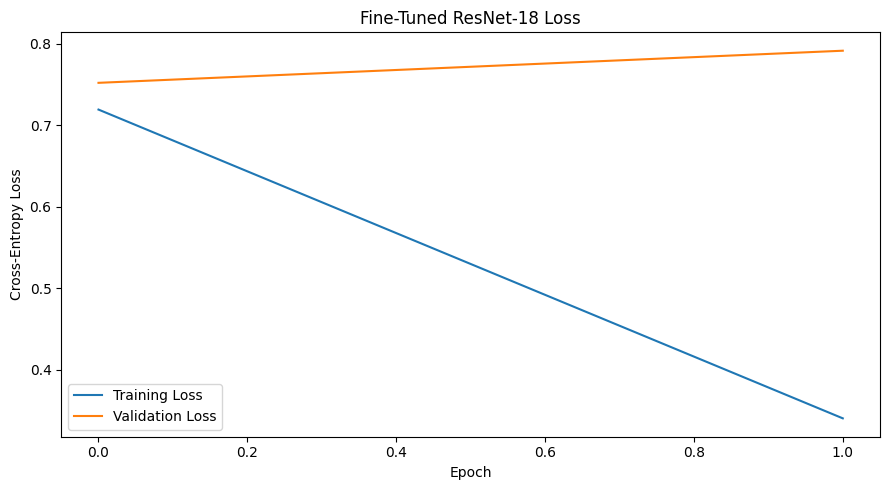

In [5]:
# Freeze the complete pretrained model first.
for parameter in finetune_resnet.parameters():
    parameter.requires_grad = False

# ResNet-18 layer4 contains the final two BasicBlock residual blocks.
for parameter in finetune_resnet.layer4.parameters():
    parameter.requires_grad = True

# Train the new classification head.
for parameter in finetune_resnet.fc.parameters():
    parameter.requires_grad = True


def classifier_loss(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    total_rows = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * len(labels)
            total_rows += len(labels)

    return total_loss / total_rows


def train_finetuned_resnet(
    model,
    train_loader,
    val_loader,
    epochs=15,
    lr=1e-4,
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
    )

    best_state = copy.deepcopy(
        model.state_dict()
    )
    best_val_loss = float("inf")

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    # The numbered requirement says train for 15 epochs, so all 15 are run.
    for epoch in range(1, epochs + 1):
        model.train()

        total_train_loss = 0.0
        total_rows = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item() * len(labels)
            )
            total_rows += len(labels)

        train_loss = (
            total_train_loss / total_rows
        )

        val_loss = classifier_loss(
            model,
            val_loader,
            criterion,
        )

        history["train_loss"].append(
            train_loss
        )
        history["val_loss"].append(
            val_loss
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(
                model.state_dict()
            )

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Validation Loss: {val_loss:.6f}"
        )

    model.load_state_dict(best_state)

    return model, history


finetune_resnet, finetune_history = (
    train_finetuned_resnet(
        finetune_resnet,
        train_image_loader,
        val_image_loader,
        epochs=2 if FAST_MODE else 15,
        lr=1e-4,
    )
)

torch.save(
    finetune_resnet.state_dict(),
    MODELS_DIR / "resnet18_finetuned_step5.pt",
)

plt.figure(figsize=(9, 5))
plt.plot(
    finetune_history["train_loss"],
    label="Training Loss",
)
plt.plot(
    finetune_history["val_loss"],
    label="Validation Loss",
)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Fine-Tuned ResNet-18 Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature extraction approach: freeze the entire network, extract 512-dimensional feature vectors, train a logistic regression on these features.

In [6]:
feature_extractor = resnet18(
    weights=weights
)

# Remove the ImageNet classifier so the output is the 512-D representation.
feature_extractor.fc = nn.Identity()
feature_extractor = feature_extractor.to(DEVICE)
feature_extractor.eval()

for parameter in feature_extractor.parameters():
    parameter.requires_grad = False


def extract_features(df):
    loader = DataLoader(
        ChartImageDataset(
            df,
            image_transform,
        ),
        batch_size=32,
        shuffle=False,
    )

    features = []
    labels = []

    with torch.no_grad():
        for images, batch_labels in loader:
            batch_features = (
                feature_extractor(
                    images.to(DEVICE)
                )
                .cpu()
                .numpy()
            )

            features.append(batch_features)
            labels.append(
                np.asarray(batch_labels)
            )

    return (
        np.vstack(features),
        np.concatenate(labels),
    )


X_train_img, y_train_img = extract_features(
    train_images_df
)
X_val_img, y_val_img = extract_features(
    val_images_df
)
X_test_img, y_test_img = extract_features(
    test_images_df
)

assert X_train_img.shape[1] == 512

feature_lr = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
)

feature_lr.fit(
    X_train_img,
    y_train_img,
)

test_feature_probs = (
    feature_lr.predict_proba(
        X_test_img
    )[:, 1]
)

joblib.dump(
    feature_lr,
    MODELS_DIR / "resnet_features_logistic_step5.joblib",
)

print(
    "Feature dimensions:",
    X_train_img.shape,
    X_val_img.shape,
    X_test_img.shape,
)


Feature dimensions: (1768, 512) (380, 512) (380, 512)


## 7. Compare: (a) fine-tuned ResNet, (b) feature extraction + logistic regression, (c) LSTM from Step 4, (d) feedforward from Step 3. Report accuracy, AUC, and Sharpe ratio.

In [7]:
def predict_resnet_probabilities(
    model,
    loader,
):
    model.eval()

    probabilities = []
    labels = []

    with torch.no_grad():
        for images, batch_labels in loader:
            logits = model(
                images.to(DEVICE)
            )

            probs = (
                torch.softmax(
                    logits,
                    dim=1,
                )[:, 1]
                .cpu()
                .numpy()
            )

            probabilities.append(probs)
            labels.append(
                np.asarray(batch_labels)
            )

    return (
        np.concatenate(probabilities),
        np.concatenate(labels),
    )


def five_day_sharpe(
    metadata_df,
    scores,
):
    strategy = metadata_df[
        [
            "Ticker",
            "Date",
            "next_5d_log_return",
        ]
    ].copy().reset_index(drop=True)

    strategy["score"] = np.asarray(scores)

    strategy["strategy_return"] = np.where(
        strategy["score"] > 0,
        strategy["next_5d_log_return"],
        0.0,
    )

    portfolio_returns = (
        strategy
        .groupby("Date")["strategy_return"]
        .mean()
        .sort_index()
    )

    if (
        len(portfolio_returns) < 2
        or portfolio_returns.std(ddof=1) == 0
    ):
        return np.nan

    # These are 5-day forward returns, so this is a simple 5-day-horizon
    # annualized Sharpe proxy for the Step 5 comparison.
    return (
        portfolio_returns.mean()
        / portfolio_returns.std(ddof=1)
        * np.sqrt(252 / 5)
    )


def comparison_metrics(
    name,
    metadata_df,
    labels,
    score,
    probability_score=False,
):
    score = np.asarray(score)

    if probability_score:
        predicted_class = (
            score >= 0.5
        ).astype(int)

        # Convert probability to a signed score for the long/flat strategy.
        strategy_score = score - 0.5
    else:
        # Step 3 and Step 4 are regression models. Their continuous
        # predicted returns are used as ranking scores.
        predicted_class = (
            score > 0
        ).astype(int)
        strategy_score = score

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            labels,
            predicted_class,
        ),
        "AUC": roc_auc_score(
            labels,
            score,
        ),
        "Sharpe Ratio": five_day_sharpe(
            metadata_df,
            strategy_score,
        ),
    }


# ----- (a) Fine-tuned ResNet -----
finetune_probs, finetune_labels = (
    predict_resnet_probabilities(
        finetune_resnet,
        test_image_loader,
    )
)

finetune_metrics = comparison_metrics(
    "Fine-Tuned ResNet-18",
    test_images_df,
    finetune_labels,
    finetune_probs,
    probability_score=True,
)


# ----- (b) Feature extraction + logistic regression -----
feature_metrics = comparison_metrics(
    "ResNet Features + Logistic Regression",
    test_images_df,
    y_test_img,
    test_feature_probs,
    probability_score=True,
)


# ----- Load the ACTUAL Step 3 model -----
STEP3_CHECKPOINT = (
    MODELS_DIR /
    "feedforward_nn_step3.pt"
)

if not STEP3_CHECKPOINT.exists():
    raise FileNotFoundError(
        "Missing ../models/feedforward_nn_step3.pt. "
        "Run the Step 3 notebook that saves the trained 3-layer model first."
    )


class FeedForwardNN(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_sizes=(128, 64, 32),
        dropout=0.3,
    ):
        super().__init__()

        layers = []
        previous_size = input_size

        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(
                    previous_size,
                    hidden_size,
                ),
                nn.BatchNorm1d(
                    hidden_size
                ),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            previous_size = hidden_size

        layers.append(
            nn.Linear(
                previous_size,
                1,
            )
        )

        self.network = nn.Sequential(
            *layers
        )

    def forward(self, x):
        return self.network(x)


step3_checkpoint = torch.load(
    STEP3_CHECKPOINT,
    map_location=DEVICE,
)

step3_model = FeedForwardNN(
    input_size=step3_checkpoint[
        "input_size"
    ],
    hidden_sizes=tuple(
        step3_checkpoint[
            "hidden_sizes"
        ]
    ),
    dropout=step3_checkpoint[
        "dropout"
    ],
).to(DEVICE)

step3_model.load_state_dict(
    step3_checkpoint[
        "model_state_dict"
    ]
)
step3_model.eval()


# ----- Load the ACTUAL Step 4 LSTM -----
STEP4_CHECKPOINT = (
    MODELS_DIR /
    "lstm_step4.pt"
)

if not STEP4_CHECKPOINT.exists():
    raise FileNotFoundError(
        "Missing ../models/lstm_step4.pt. "
        "At the end of Step 4 training, save the trained 60-day LSTM "
        "with torch.save({'model_state_dict': lstm_model.state_dict(), "
        "'input_size': len(FEATURE_COLS), 'hidden_size': 64, "
        "'num_layers': 2, 'dropout': 0.3, 'sequence_length': 60}, "
        "MODELS_DIR / 'lstm_step4.pt')."
    )


class LSTMRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=2,
        dropout=0.3,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout,
            batch_first=True,
        )

        self.output = nn.Linear(
            hidden_size,
            1,
        )

    def forward(self, x):
        sequence_output, _ = self.lstm(x)
        return self.output(
            sequence_output[:, -1, :]
        ).squeeze(1)


step4_checkpoint = torch.load(
    STEP4_CHECKPOINT,
    map_location=DEVICE,
)

step4_model = LSTMRegressor(
    input_size=step4_checkpoint[
        "input_size"
    ],
    hidden_size=step4_checkpoint[
        "hidden_size"
    ],
    num_layers=step4_checkpoint[
        "num_layers"
    ],
    dropout=step4_checkpoint[
        "dropout"
    ],
).to(DEVICE)

step4_model.load_state_dict(
    step4_checkpoint[
        "model_state_dict"
    ]
)
step4_model.eval()

STEP4_SEQUENCE_LENGTH = (
    step4_checkpoint[
        "sequence_length"
    ]
)


# Step 3 and Step 4 were trained for NEXT-DAY RETURN regression,
# while Step 5 labels are NEXT-5-DAY DIRECTION. The curriculum still asks
# for a direct comparison. Therefore their native continuous return forecasts
# are used as scores against the Step 5 labels. This is a horizon-mismatched
# comparison and should be stated as a limitation in the final discussion.

FEATURE_COLS = joblib.load(
    MODELS_DIR /
    "feature_cols.joblib"
)

all_processed = (
    pd.concat(
        [
            train_tabular,
            val_tabular,
            test_tabular,
        ],
        ignore_index=True,
    )
    .sort_values(
        ["Ticker", "Date"]
    )
    .drop_duplicates(
        ["Ticker", "Date"],
        keep="last",
    )
    .reset_index(drop=True)
)


# ----- Step 3 scores on the same Step 5 test samples -----
step3_test = (
    test_images_df[
        [
            "Ticker",
            "Date",
            "label",
            "next_5d_log_return",
        ]
    ]
    .merge(
        all_processed[
            ["Ticker", "Date"] +
            FEATURE_COLS
        ],
        on=["Ticker", "Date"],
        how="inner",
    )
    .dropna(
        subset=FEATURE_COLS
    )
    .reset_index(drop=True)
)

with torch.no_grad():
    step3_scores = (
        step3_model(
            torch.tensor(
                step3_test[
                    FEATURE_COLS
                ].to_numpy(
                    np.float32
                ),
                device=DEVICE,
            )
        )
        .squeeze(1)
        .cpu()
        .numpy()
    )

step3_metrics = comparison_metrics(
    "Feedforward NN (Step 3)",
    step3_test,
    step3_test[
        "label"
    ].to_numpy(),
    step3_scores,
    probability_score=False,
)


# ----- Step 4 60-day sequences ending on Step 5 test dates -----
wanted_test_dates = set(
    zip(
        test_images_df["Ticker"],
        pd.to_datetime(
            test_images_df["Date"]
        ),
    )
)

X_lstm = []
meta_lstm = []

for ticker, stock in (
    all_processed[
        all_processed["Ticker"].isin(
            SELECTED_TICKERS
        )
    ]
    .sort_values(["Ticker", "Date"])
    .groupby("Ticker", sort=False)
):
    stock = (
        stock
        .sort_values("Date")
        .reset_index(drop=True)
    )

    feature_matrix = (
        stock[FEATURE_COLS]
        .to_numpy(np.float32)
    )

    dates = pd.to_datetime(
        stock["Date"]
    )

    for i in range(
        STEP4_SEQUENCE_LENGTH - 1,
        len(stock),
    ):
        key = (
            ticker,
            pd.Timestamp(
                dates.iloc[i]
            ),
        )

        if key not in wanted_test_dates:
            continue

        window = feature_matrix[
            i - STEP4_SEQUENCE_LENGTH + 1:
            i + 1
        ]

        if not np.isfinite(
            window
        ).all():
            continue

        X_lstm.append(window)
        meta_lstm.append(key)

X_lstm = np.stack(
    X_lstm
).astype(np.float32)

step4_model.eval()

with torch.no_grad():
    step4_scores = (
        step4_model(
            torch.tensor(
                X_lstm,
                device=DEVICE,
            )
        )
        .cpu()
        .numpy()
    )

step4_meta = pd.DataFrame(
    meta_lstm,
    columns=[
        "Ticker",
        "Date",
    ],
)

step4_eval = (
    step4_meta
    .merge(
        test_images_df[
            [
                "Ticker",
                "Date",
                "label",
                "next_5d_log_return",
            ]
        ],
        on=["Ticker", "Date"],
        how="inner",
    )
    .reset_index(drop=True)
)

step4_metrics = comparison_metrics(
    "LSTM (Step 4)",
    step4_eval,
    step4_eval[
        "label"
    ].to_numpy(),
    step4_scores,
    probability_score=False,
)


comparison = (
    pd.DataFrame([
        finetune_metrics,
        feature_metrics,
        step4_metrics,
        step3_metrics,
    ])
    .set_index("Model")
)

display(comparison)

print(
    "Important limitation: Step 3 and Step 4 are next-day return "
    "regression models, whereas Step 5 is a 5-day direction task. "
    "Their continuous forecasts are used here only because the curriculum "
    "explicitly asks for this four-model comparison."
)


,Accuracy,AUC,Sharpe Ratio
Model,,,
Fine-Tuned ResNet-18,0.497368,0.547590,1.422738
ResNet Features + Logistic Regression,0.536842,0.527358,1.790773
LSTM (Step 4),0.494737,0.513450,1.416399
Feedforward NN (Step 3),0.552632,0.475418,2.310779


Important limitation: Step 3 and Step 4 are next-day return regression models, whereas Step 5 is a 5-day direction task. Their continuous forecasts are used here only because the curriculum explicitly asks for this four-model comparison.


## 8. Visualize with Grad-CAM: which chart regions does the model focus on?

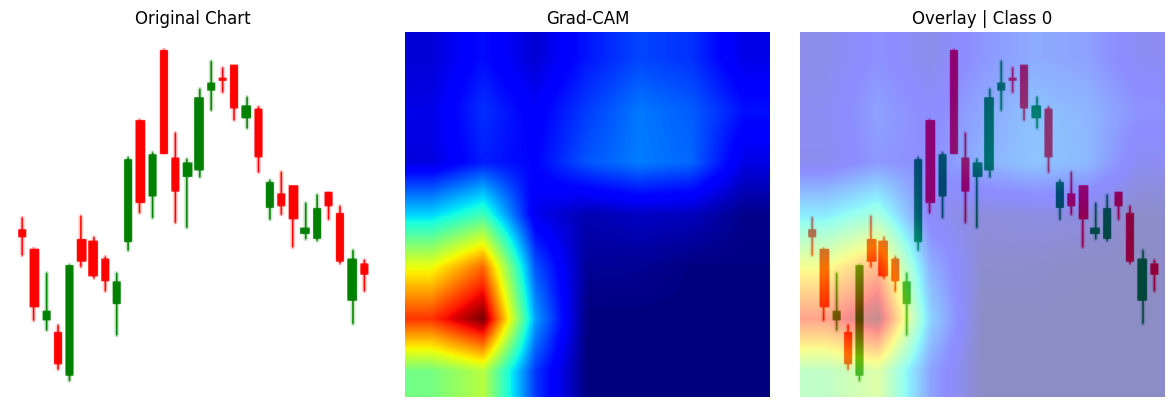

Ticker: NVDA
Date: 2023-09-19 00:00:00
Probability of positive 5-day return: 0.07380098104476929


In [8]:
class GradCAM:
    def __init__(
        self,
        model,
        target_layer,
    ):
        self.model = model
        self.activations = None
        self.gradients = None

        self.forward_handle = (
            target_layer.register_forward_hook(
                self._forward_hook
            )
        )

        self.backward_handle = (
            target_layer.register_full_backward_hook(
                self._backward_hook
            )
        )

    def _forward_hook(
        self,
        module,
        inputs,
        output,
    ):
        self.activations = output

    def _backward_hook(
        self,
        module,
        grad_input,
        grad_output,
    ):
        self.gradients = grad_output[0]

    def generate(
        self,
        input_tensor,
        class_idx=None,
    ):
        self.model.zero_grad(
            set_to_none=True
        )

        logits = self.model(
            input_tensor
        )

        if class_idx is None:
            class_idx = int(
                logits.argmax(
                    dim=1
                ).item()
            )

        logits[:, class_idx].sum().backward()

        weights = (
            self.gradients
            .mean(
                dim=(2, 3),
                keepdim=True,
            )
        )

        cam = (
            weights *
            self.activations
        ).sum(
            dim=1,
            keepdim=True,
        )

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(224, 224),
            mode="bilinear",
            align_corners=False,
        )

        cam = (
            cam
            .squeeze()
            .detach()
            .cpu()
            .numpy()
        )

        cam -= cam.min()
        cam /= (
            cam.max() + 1e-8
        )

        return cam, class_idx

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()


# Select a confident test prediction for a clear example.
example_index = int(
    np.argmax(
        np.abs(
            finetune_probs - 0.5
        )
    )
)

example_row = (
    test_images_df
    .reset_index(drop=True)
    .iloc[example_index]
)

raw_image = Image.open(
    example_row["image_path"]
).convert("RGB")

input_tensor = (
    image_transform(raw_image)
    .unsqueeze(0)
    .to(DEVICE)
)

# Grad-CAM on the final convolution of the final residual block.
gradcam = GradCAM(
    finetune_resnet,
    finetune_resnet.layer4[-1].conv2,
)

heatmap, predicted_class = (
    gradcam.generate(
        input_tensor
    )
)

gradcam.close()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(raw_image)
plt.title("Original Chart")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(
    heatmap,
    cmap="jet",
)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(raw_image)
plt.imshow(
    heatmap,
    cmap="jet",
    alpha=0.45,
)
plt.title(
    f"Overlay | Class {predicted_class}"
)
plt.axis("off")

plt.tight_layout()
plt.show()

print("Ticker:", example_row["Ticker"])
print("Date:", example_row["Date"])
print(
    "Probability of positive 5-day return:",
    float(
        finetune_probs[
            example_index
        ]
    ),
)
